In [1]:
# Desarrollo del laboratorio 2 de la clase 24-06

In [2]:
#Importamos las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
file = "./laptop_pricing_dataset_mod1.csv"

In [4]:
df = pd.read_csv(file , index_col=0)
df.sample(15)

,Manufacturer,Category,Screen,GPU,OS,CPU_core,Screen_Size_cm,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_kg,Price
177,HP,3,Full HD,3,1,7,43.942,2.7,8,256,2.63,1524
99,Dell,5,IPS Panel,3,1,7,38.100,2.7,8,256,2.00,2712
95,Dell,3,Full HD,1,1,7,39.624,2.7,8,256,2.33,1142
11,HP,3,Full HD,2,1,3,39.624,2.0,4,128,1.91,558
69,Lenovo,1,IPS Panel,3,1,5,38.100,2.5,8,256,2.50,1053
218,Dell,3,Full HD,2,1,5,35.560,2.8,8,256,1.60,1531
26,Asus,3,Full HD,3,1,3,39.624,2.4,6,256,2.00,733
64,Asus,1,Full HD,3,1,7,43.942,2.9,16,256,3.60,3810
120,Dell,4,Full HD,2,1,5,NaN,1.6,8,256,1.42,2340
14,Asus,3,Full HD,2,1,5,35.560,1.6,8,256,1.40,1195


In [5]:
print("\n Información ")
df.info()


 Información 
<class 'pandas.DataFrame'>
RangeIndex: 238 entries, 0 to 237
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Manufacturer    238 non-null    str    
 1   Category        238 non-null    int64  
 2   Screen          238 non-null    str    
 3   GPU             238 non-null    int64  
 4   OS              238 non-null    int64  
 5   CPU_core        238 non-null    int64  
 6   Screen_Size_cm  234 non-null    float64
 7   CPU_frequency   238 non-null    float64
 8   RAM_GB          238 non-null    int64  
 9   Storage_GB_SSD  238 non-null    int64  
 10  Weight_kg       233 non-null    float64
 11  Price           238 non-null    int64  
dtypes: float64(3), int64(7), str(2)
memory usage: 22.4 KB


In [6]:
df.columns

Index(['Manufacturer', 'Category', 'Screen', 'GPU', 'OS', 'CPU_core',
       'Screen_Size_cm', 'CPU_frequency', 'RAM_GB', 'Storage_GB_SSD',
       'Weight_kg', 'Price'],
      dtype='str')

In [7]:
# Tarea 1: Tratamiento de Valores Faltantes (Missing Values)
#En esta sección, el objetivo es identificar y gestionar los datos ausentes en el dataset.

In [8]:
df.replace('?', np.nan, inplace=True).head(15)

,Manufacturer,Category,Screen,GPU,OS,CPU_core,Screen_Size_cm,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_kg,Price
0,Acer,4,IPS Panel,2,1,5,35.560,1.6,8,256,1.60,978
1,Dell,3,Full HD,1,1,3,39.624,2.0,4,256,2.20,634
2,Dell,3,Full HD,1,1,7,39.624,2.7,8,256,2.20,946
3,Dell,4,IPS Panel,2,1,5,33.782,1.6,8,128,1.22,1244
4,HP,4,Full HD,2,1,7,39.624,1.8,8,256,1.91,837
5,Dell,3,Full HD,1,1,5,39.624,1.6,8,256,2.20,1016
6,HP,3,Full HD,3,1,5,39.624,1.6,8,256,2.10,1117
7,Acer,3,IPS Panel,2,1,5,38.100,1.6,4,256,2.20,866
8,Dell,3,Full HD,1,1,5,39.624,2.5,4,256,2.30,812
9,Acer,3,IPS Panel,3,1,7,38.100,1.8,8,256,2.20,1068


In [9]:
null_counts = df.isnull().sum()
print("Cantidad de valores faltantes por columna:")
print(null_counts[null_counts > 0])

Cantidad de valores faltantes por columna:
Screen_Size_cm    4
Weight_kg         5
dtype: int64


In [10]:
# Tarea 2:  Reemplazar con media. 
# Cabe destacar que los valores del atributo "Peso_kg" son continuos y faltan algunos. 

In [11]:
# float temporal para calcular la media de los valores del atributo "Weight_kg"

avg_weight = df['Weight_kg'].astype('float').mean(axis=0)
print(f"Media calculada para Weight_kg: {avg_weight:.3f}")

Media calculada para Weight_kg: 1.862


In [12]:
df['Weight_kg'] = df['Weight_kg'].replace(np.nan, avg_weight)
df['Weight_kg'] = df['Weight_kg'].replace(np.nan, avg_weight)
df['Weight_kg']  

0      1.60
1      2.20
2      2.20
3      1.22
4      1.91
       ... 
233    1.70
234    1.20
235    1.36
236    2.40
237    1.95
Name: Weight_kg, Length: 238, dtype: float64

In [13]:
most_frequent_screen = df['Screen_Size_cm'].value_counts().idxmax()
print(f"Valor más frecuente en Screen_Size_cm: {most_frequent_screen}")

Valor más frecuente en Screen_Size_cm: 39.624


In [14]:
# 2. Reemplazar los valores faltantes con el más frecuente
df['Screen_Size_cm'] = df['Screen_Size_cm'].replace(np.nan, most_frequent_screen)
print("\nValores nulos restantes en el dataset:", df.isnull().sum().sum())


Valores nulos restantes en el dataset: 0


In [15]:
# Tarea 3: Corregir los tipos de datos

In [16]:
# convertir
df[['Weight_kg', 'Screen_Size_cm']] = df[['Weight_kg', 'Screen_Size_cm']].astype('float')
print(df.dtypes[['Weight_kg', 'Screen_Size_cm']])

Weight_kg         float64
Screen_Size_cm    float64
dtype: object


In [17]:
# Tarea 4:  Estandarización de datos y normalización 

In [18]:
df['Screen_Size_cm'] = df['Screen_Size_cm'] / 2.54
df.rename(columns={'Screen_Size_cm': 'Screen_Size_inch'}, inplace=True)


In [19]:
df['Weight_kg'] = df['Weight_kg'] * 2.205
df.rename(columns={'Weight_kg': 'Weight_lbs'}, inplace=True)

In [20]:
max_cpu_freq = df['CPU_frequency'].max()
df['CPU_frequency'] = df['CPU_frequency'] / max_cpu_freq


In [21]:
print(df.columns)

Index(['Manufacturer', 'Category', 'Screen', 'GPU', 'OS', 'CPU_core',
       'Screen_Size_inch', 'CPU_frequency', 'RAM_GB', 'Storage_GB_SSD',
       'Weight_lbs', 'Price'],
      dtype='str')


In [22]:
print(df[['Screen_Size_inch', 'Weight_lbs', 'CPU_frequency']].head())

   Screen_Size_inch  Weight_lbs  CPU_frequency
0              14.0     3.52800       0.551724
1              15.6     4.85100       0.689655
2              15.6     4.85100       0.931034
3              13.3     2.69010       0.551724
4              15.6     4.21155       0.620690


In [23]:
# Tarea 5: Agrupamiento (Binning) 

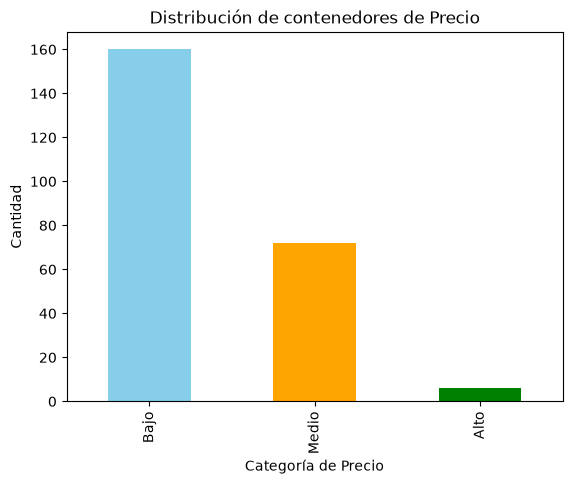

In [24]:
# 1. Crear los 3 contenedores (bins) basados en el mínimo y máximo de los precios
bins = np.linspace(min(df['Price']), max(df['Price']), 4)

# 2. Definir las etiquetas para los grupos
nombres_grupos = ['Bajo', 'Medio', 'Alto']

# 3. Crear la nueva columna categorizada
df['Agrupamiento de precios'] = pd.cut(df['Price'], bins, labels=nombres_grupos, include_lowest=True)

# 4. Dibujar el gráfico de barras
df['Agrupamiento de precios'].value_counts().plot(kind='bar', color=['skyblue', 'orange', 'green'])
plt.title('Distribución de contenedores de Precio')
plt.xlabel('Categoría de Precio')
plt.ylabel('Cantidad')
plt.show()

In [25]:
# Tarea 6: Variables ficticias o indicadoras. (one hot encoding)

In [26]:
# Paso 1: Generar las columnas indicadoras (convertidas a enteros 0 y 1)
dummy_screen = pd.get_dummies(df['Screen'], dtype=int)

# Paso 2: Renombrar las columnas generadas
dummy_screen.rename(columns={
    'IPS Panel': 'Pantalla-IPS_panel',
    'Full HD': 'Pantalla-Full_HD'
}, inplace=True)

# Paso 3: Concatenar las nuevas columnas ficticias al DataFrame principal
df = pd.concat([df, dummy_screen], axis=1)

# Paso 4: Eliminar la columna categórica original 'Screen'
df.drop('Screen', axis=1, inplace=True)

# Paso 5: Guardar el dataset limpio final en un archivo CSV
output_csv = "clean_df.csv"
df.to_csv(output_csv, index=False)

print(f"El dataset limpio ha sido guardado exitosamente como '{output_csv}'")

El dataset limpio ha sido guardado exitosamente como 'clean_df.csv'


In [27]:
# Realiado por GJ